In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf 
from tensorflow.keras import layers, Model
import os
import glob

In [39]:
train_data_path = sorted(glob.glob("bdd100k_seg/bdd100k/seg/images/train/*.jpg"))
train_output_path = sorted(glob.glob("bdd100k_seg/bdd100k/seg/labels/train/*.png"))

val_data_path = sorted(glob.glob("bdd100k_seg/bdd100k/seg/images/val/*.jpg"))
val_output_path = sorted(glob.glob("bdd100k_seg/bdd100k/seg/labels/val/*.png"))

test_data_path = sorted(glob.glob("bdd100k_seg/bdd100k/seg/images/test/*.jpg"))

train_dataset = tf.data.Dataset.from_tensor_slices((train_data_path, train_output_path))
val_dataset = tf.data.Dataset.from_tensor_slices((val_data_path, val_output_path))
test_dataset = tf.data.Dataset.from_tensor_slices(test_data_path)

In [ ]:
IMG_SIZE = (224, 224)
def load_image(image_path, mask_path):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0

    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.resize(mask, IMG_SIZE, method= "nearest")
    mask = tf.cast(mask, tf.int32)
    mask = tf.squeeze(mask, axis=-1)
    mask = tf.clip_by_value(mask, 0, 18)

    return image, mask

In [23]:
train_dataset = train_dataset.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
val_dataset = val_dataset.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
BATCH_SIZE = 16
train_dataset = train_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [24]:
base_model = tf.keras.applications.ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
layer_names = ["conv2_block3_out", "conv3_block4_out", "conv4_block6_out", "conv5_block3_out"]
layer_outputs = [base_model.get_layer(name).output for name in layer_names]
encoder = Model(inputs=base_model.input, outputs=layer_outputs)

In [25]:
inputs = layers.Input(shape=(224, 224, 3))
features = encoder(inputs)
aligned_features = []
for feature in features:
    x = layers.Conv2D(64, kernel_size = 1, padding = "same")(feature)
    x  = layers.Resizing(56, 56)(x)
    aligned_features.append(x)
sequence = layers.Lambda(lambda x: tf.stack(x, axis=1))(aligned_features)
x = layers.ConvLSTM2D(64, kernel_size = 3, padding = "same", return_sequences = False)(sequence)
x = layers.Conv2DTranspose(64, kernel_size = 3, strides = 2, padding = "same", activation = "relu")(x)
x = layers.Conv2DTranspose(64, kernel_size = 3, strides = 2, padding = "same", activation = "relu")(x)
outputs = layers.Conv2D(19, kernel_size = 1, activation = "softmax")(x)
model = Model(inputs=inputs, outputs=outputs)
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional_3        │ [(None, 56, 56,   │ 23,587,712 │ input_layer_4[0]… │
│ (Functional)        │ 256), (None, 28,  │            │                   │
│                     │ 28, 512), (None,  │            │                   │
│                     │ 14, 14, 1024),    │            │                   │
│                     │ (None, 7, 7,      │            │                   │
│                     │ 2048)]            │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 56, 56,    │     16,448 │ functional_3[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 28, 28,    │     32,832 │ functional_3[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 14, 14,    │     65,600 │ functional_3[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 7, 7, 64)  │    131,136 │ functional_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resizing_8          │ (None, 56, 56,    │          0 │ conv2d_10[0][0]   │
│ (Resizing)          │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resizing_9          │ (None, 56, 56,    │          0 │ conv2d_11[0][0]   │
│ (Resizing)          │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resizing_10         │ (None, 56, 56,    │          0 │ conv2d_12[0][0]   │
│ (Resizing)          │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resizing_11         │ (None, 56, 56,    │          0 │ conv2d_13[0][0]   │
│ (Resizing)          │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_2 (Lambda)   │ (None, 4, 56, 56, │          0 │ resizing_8[0][0], │
│                     │ 64)               │            │ resizing_9[0][0], │
│                     │                   │            │ resizing_10[0][0… │
│                     │                   │            │ resizing_11[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_lstm2d_2       │ (None, 56, 56,    │    295,168 │ lambda_2[0][0]    │
│ (ConvLSTM2D)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_5  │ (None, 112, 112,  │     36,928 │ conv_lstm2d_2[0]… │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_6  │ (None, 224, 224,  │     36,928 │ conv2d_transpose… │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_14 (Conv2D)  │ (None, 224, 224,  │      1,235 │ conv2d_transpose… │
│                     │ 19)               │            │                 

 Total params: 24,203,987 (92.33 MB)

 Trainable params: 24,150,867 (92.13 MB)

 Non-trainable params: 53,120 (207.50 KB)

Epoch 1/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 1258s 3s/step - accuracy: 0.6865 - loss: 1.0485 - val_accuracy: 0.1440 - val_loss: 2.1549
Epoch 2/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 1230s 3s/step - accuracy: 0.7640 - loss: 0.8158 - val_accuracy: 0.5415 - val_loss: 1.5433
Epoch 3/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 1228s 3s/step - accuracy: 0.7916 - loss: 0.7200 - val_accuracy: 0.7016 - val_loss: 1.0005
Epoch 4/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 1241s 3s/step - accuracy: 0.8068 - loss: 0.6674 - val_accuracy: 0.8142 - val_loss: 0.6333
Epoch 5/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 1238s 3s/step - accuracy: 0.8180 - loss: 0.6270 - val_accuracy: 0.7876 - val_loss: 0.7058
Epoch 6/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 1237s 3s/step - accuracy: 0.8273 - loss: 0.5957 - val_accuracy: 0.7731 - val_loss: 0.7371
Epoch 7/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 1239s 3s/step - accuracy: 0.8336 - loss: 0.5718 - val_accuracy: 0.7975 - val_loss: 0.6787
Epoch 8/30
438/438 ━━━━━━━━━━━━━━━━━━━━ 1240s 3s/step - accuracy: 0.8418 - loss: 0.5436 - 

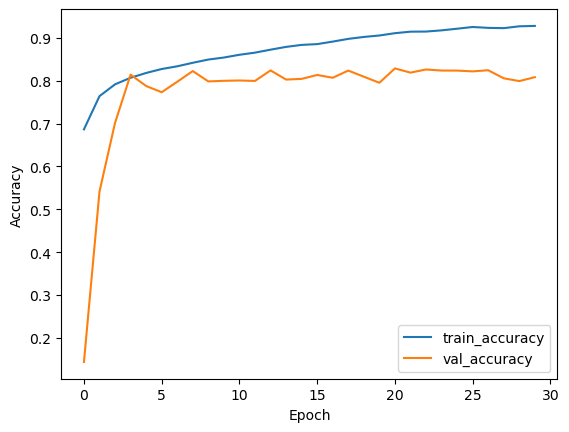

In [26]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(train_dataset, validation_data=val_dataset, epochs=30)
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [40]:
def load_test_image(image_path):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    return image
test_dataset = test_dataset.map(load_test_image, num_parallel_calls=tf.data.AUTOTUNE)
test_dataset = test_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
predictions = model.predict(test_dataset.unbatch().take(10).batch(10))
predicted_classes = np.argmax(predictions, axis=-1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


c:\Users\zeyad\anaconda3\envs\ml\lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


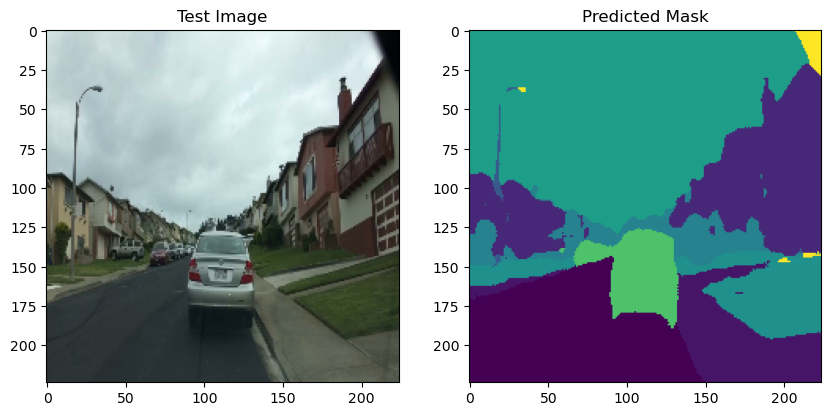

In [41]:
test_image = load_test_image(test_data_path[0])
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(test_image)
plt.title("Test Image")
plt.subplot(1, 2, 2)
plt.imshow(predicted_classes[0])
plt.title("Predicted Mask")
plt.show()